<a href="https://colab.research.google.com/github/juliablaz2003/NLP/blob/main/NLP_hands_on_1_tokenization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Huggingface

This is the reference hub to work with Large Language Models !!!


https://huggingface.co/

Contains tons of repositories:
- Models
- Datasets
- ...

Take some time to explore it properly...

Tokenizer


We will use the `transformers` library, developed by the huggingface team.

Here are implemented most of the tokenizer algorithm.

You can download pretrained models from huggingface repository.

https://huggingface.co/docs/tokenizers/index


In [ ]:
!pip install transformers

In [ ]:
# import the tokenizer facilities

from transformers import AutoTokenizer

In [ ]:
# download a tokenizer from a huggingface's model

mistral_t = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.1")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [ ]:
# How many tokens?

print("mistral's tokenizer number of tokens:", mistral_t.vocab_size)

mistral's tokenizer number of tokens: 32000


In [ ]:
# select a random English text

test_text = "hello, my name is Luca and I love listening to music"

encoded_test_text = mistral_t.tokenize(test_text)

print(encoded_test_text)

['▁hell', 'o', ',', '▁my', '▁name', '▁is', '▁Luc', 'a', '▁and', '▁I', '▁love', '▁listening', '▁to', '▁music']


In [ ]:
# how many tokens?

print("number of words: 11")
print("number of tokens:", len(encoded_test_text))

number of words: 11
number of tokens: 14


In [ ]:
# select a random Italian text

test_text = "Ciao, mi chiamo Luca e mi piace molto ascoltare la musica elettronica"

encoded_test_text = mistral_t.tokenize(test_text)

print(encoded_test_text)

['▁C', 'iao', ',', '▁mi', '▁ch', 'iam', 'o', '▁Luc', 'a', '▁e', '▁mi', '▁pi', 'ace', '▁molto', '▁as', 'col', 't', 'are', '▁la', '▁mus', 'ica', '▁e', 'let', 'tr', 'on', 'ica']


In [ ]:
# how many tokens?

print("number of words: 11")
print("number of tokens:", len(encoded_test_text))

number of words: 11
number of tokens: 26


In [ ]:
# Can you spot a first problem?

# Let's try to use an English-Italian tokenizer! (Minerva :))

# download a tokenizer from a huggingface's model

minerva_t = AutoTokenizer.from_pretrained("sapienzanlp/Minerva-7B-base-v1.0")

config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/868 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [ ]:
# how many tokens?

print("minerva's tokenizer number of tokens:", minerva_t.vocab_size)

minerva's tokenizer number of tokens: 51200


In [ ]:
# select a random English text

test_text = "hello, my name is Luca and I love listening to music"

encoded_test_text = minerva_t.tokenize(test_text)

print(encoded_test_text)

['Ġhello', ',', 'Ġmy', 'Ġname', 'Ġis', 'ĠLuca', 'Ġand', 'ĠI', 'Ġlove', 'Ġlistening', 'Ġto', 'Ġmusic']


In [ ]:
# how many tokens?

print("number of words: 11")
print("number of tokens:", len(encoded_test_text))

number of words: 11
number of tokens: 12


In [ ]:
# select a random Italian text

test_text = "Ciao, mi chiamo Luca e mi piace molto ascoltare la musica elettronica"

encoded_test_text = minerva_t.tokenize(test_text)

print(encoded_test_text)

['ĠCiao', ',', 'Ġmi', 'Ġchiamo', 'ĠLuca', 'Ġe', 'Ġmi', 'Ġpiace', 'Ġmolto', 'Ġascoltare', 'Ġla', 'Ġmusica', 'Ġelettronica']


In [ ]:
# how many tokens?

print("number of words: 11")
print("number of tokens:", len(encoded_test_text))

number of words: 11
number of tokens: 13


In [ ]:
# ... now is better :)

# Fertility: average number of tokens per word.

Given a text $X$, the fertility of the tokenizer $T$ over such text $F_T$, is computed as follow:

$F_T(X) = \frac{len(T(X))}{len(words(X))}$.

Where $T(X)$ return the list of tokens from $X$ and $words$ return the list of words contained in $X$.


Usually lower is better.

Less number of tokens per word imply to have faster generation:
- Less number of iteration of a encode/decoder pipeline to process a text.
- Each token can contains more structure informations, avoid ambiguity.

In [ ]:
# install required pakages

In [ ]:
!pip install nltk
!pip install datasets

In [ ]:
from nltk.tokenize import word_tokenize # word splitter (based on handcrafted patterns.)
from tqdm import tqdm
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
def compute_fertility(tokenizer, text, language="english", spm=False):
  words = word_tokenize(text, language=language)
  if spm:
    tokens_id = tokenizer.encode(text)
  else:
    tokens_id = tokenizer(text, add_special_tokens=False).input_ids

  sample_fertility = len(tokens_id) / len(words)
  return sample_fertility

# Huggingface: Datasets

The dataset library, developed by huggingface team, is a tool that let you to download and process multimodal data from huggingface repositories. (take a look at some examples).

https://huggingface.co/docs/datasets/index


Here we will use the preprocessed and cleaned text from wikipedia:
- HuggingFaceFW/finewiki


Since the huggingface datasets are too huge, we will load data one sample at each, using the `streaming` functionality.
- multilingual Wikipedia are 200 GBs!

In [ ]:
from datasets import load_dataset

ds = load_dataset("HuggingFaceFW/finewiki", name="it", split="train", streaming=True)

README.md: 0.00B [00:00, ?B/s]

In [ ]:
for sample in ds:
  text_sample = sample["text"]
  break

In [ ]:
print(text_sample)

# .co
.co è il dominio di primo livello nazionale assegnato alla Colombia.
Originariamente gestito dalla Universidad de los Andes, è amministrato dalla società per azioni .CO Internet, dietro mandato del Ministerio de Tecnologías de la Información y las Comunicaciones (MinTIC). Nel 2014 .CO Internet è stata acquistata da Neustar, successivamente diventata parte di GoDaddy.
Il dominio è considerato importante per via della somiglianza con .com e viene trattato da alcuni motori di ricerca come .tv o .me.


In [ ]:
compute_fertility(minerva_t, text_sample, "italian")

1.367816091954023

In [ ]:
compute_fertility(mistral_t, text_sample, "italian")

1.7011494252873562

# Let's Analyze More Data


Let's try the following tokenizers, from open access models in huggingface:

- Mistral-v0.1
- Minerva-7B
- Qwen2.5


Using the fertility function defined above. Try to answer the following question: "Which is the best tokenizer if I want to work with: 'Italian', 'Greek', and 'Basque'"?

TODO:
- Select 3/4 tokenizers, with varying vocabulary size, and language coverage.
- For each language get n. pages from wikipedia (choose a reasonable number) and compute an average fertility scoring.
- Create a brief report with cool plots that analyze the behaviour of tokenizers across languages and dimension of the vocabularies, with some interesting qualitative examples.

In [ ]:
# compute average fertility score!

import statistics

LANGS = {"it": "italian",
         "el": "greek",
         "eu": "italian"} # use Italian word tokenizer for basque!


def compute_average_fertility_on_language(tokenizer, language, pages, spm=False):
  ds = load_dataset("HuggingFaceFW/finewiki", name=language, split="train", streaming=True)

  fertilities = []

  for i, sample in enumerate(tqdm(ds)):
    if i == pages:
      break

    fertilities.append(compute_fertility(tokenizer, sample["text"], language=LANGS[language], spm=spm))

  return statistics.mean(fertilities)

In [ ]:
minerva_t = AutoTokenizer.from_pretrained("sapienzanlp/Minerva-7B-base-v1.0")
mistral_t = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.1")
qwen_t = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
print("Vocabulary Size of Minerva's tokenizer:", minerva_t.vocab_size)
print("Vocabulary Size of Mistral's tokenizer:", mistral_t.vocab_size)
print("Vocabulary Size of Qwen's tokenizer:", qwen_t.vocab_size)

Vocabulary Size of Minerva's tokenizer: 51200
Vocabulary Size of Mistral's tokenizer: 32000
Vocabulary Size of Qwen's tokenizer: 151643


In [ ]:
# Italian analysis
minerva_italian_analysis = compute_average_fertility_on_language(minerva_t, "it", 10)
mistral_italian_analysis = compute_average_fertility_on_language(mistral_t, "it", 10)
qwen_italian_analysis = compute_average_fertility_on_language(qwen_t, "it", 10)


print("minerva italian analysis:",  minerva_italian_analysis)
print("mistral italian analysis:",  mistral_italian_analysis)
print("qwen italian analysis:",  qwen_italian_analysis)

10it [00:01,  5.29it/s]
10it [00:01,  5.49it/s]
10it [00:01,  5.36it/s]

minerva italian analysis: 1.673737362775937
mistral italian analysis: 2.044700884258112
qwen italian analysis: 1.899419609779816


In [ ]:
# Greek analysis
minerva_greek_analysis = compute_average_fertility_on_language(minerva_t, "el", 10)
mistral_greek_analysis = compute_average_fertility_on_language(mistral_t, "el", 10)
qwen_greek_analysis = compute_average_fertility_on_language(qwen_t, "el", 10)


print("minerva greek analysis:",  minerva_greek_analysis)
print("mistral greek analysis:",  mistral_greek_analysis)
print("qwen greek analysis:",  qwen_greek_analysis)

10it [00:01,  5.10it/s]
10it [00:01,  5.14it/s]
10it [00:01,  5.16it/s]

minerva greek analysis: 5.485889014191668
mistral greek analysis: 5.159097899623262
qwen greek analysis: 4.469125531347784


In [ ]:
# Basque analysis
minerva_basque_analysis = compute_average_fertility_on_language(minerva_t, "eu", 10)
mistral_basque_analysis = compute_average_fertility_on_language(mistral_t, "eu", 10)
qwen_basque_analysis = compute_average_fertility_on_language(qwen_t, "eu", 10)


print("minerva basque analysis:",  minerva_basque_analysis)
print("mistral basque analysis:",  mistral_basque_analysis)
print("qwen basque analysis:",  qwen_basque_analysis)

10it [00:01,  5.46it/s]
10it [00:01,  6.24it/s]
10it [00:01,  6.00it/s]

minerva basque analysis: 2.7781315949536434
mistral basque analysis: 2.870609247210341
qwen basque analysis: 2.5897255213561126


# Train your own tokenizer

Here we can try to create our own tokenizer using the Google library `sentencepiece`.

Link: https://github.com/google/sentencepiece/

This library implement the BPE algorithm in a optimized way.

We can rely on this library to train our personal tokenizer.

In [ ]:
!pip install sentencepiece

In [ ]:
# preprocess a bunch of plain text data

In [ ]:
# save a bunch of basque and greek pages
# since we have seen that such low resource languages cannot be handled well by English and Italian tokenizers
# so, let's train a tokenizer specific for those languages

In [ ]:
# collect greek
greek_text = ""

# get greek data
fw = load_dataset("HuggingFaceFW/finewiki", name="el", split="train", streaming=True)

for i, el in enumerate(fw):
  if i < 10:
      continue

  greek_text += el["text"]+"\n"

  if i == 100:
    break

with open("greek_train.txt", "w") as f:
  f.write(greek_text)


In [ ]:
# collect basque
basque_text = ""

# get basque data
fw = load_dataset("HuggingFaceFW/finewiki", name="eu", split="train", streaming=True)

for i, el in enumerate(fw):
  if i < 10:
      continue

  basque_text += el["text"]+"\n"

  if i == 100:
    break

with open("basque_train.txt", "w") as f:
  f.write(basque_text)

In [ ]:
# see the downloaded data
!head basque_train.txt

# Liu Haili
Liu Haili (Haicheng, 1984ko abenduaren 24a) atleta da. Txinako Herri Errepublika ordezkatu zuen 2008ko Udako Olinpiar Jokoetan.

# Chola kapela
Chola kapela onddo-kapelaren aldaera bat da, Bolivian emakume indigenek, chola edo cholita esaten zaienek, erabiltzen dutena. Batez ere La Paz hiriko emakumeen artean da erabilia, eta 1920ko hamarkadatik aurrera hedatu zen kapela hau janzteko moda.
Ohitura dago zuzen eramateko buru gainean, emakume ezkonduen kasuan, eta alde batera alboratua ezkongabe edo alargunen kasuan.
Ez da onddo-kapela hau Boliviako emakume indigenek darabilten buruko mota bakarra, kopa kapela zuriak, qhochala zabalak, eta beste batzuk ere erabiltzen dira, segun etniak eta eskualdeak. 

## Iruditegia
- Hiru emakumezko indigena.


In [ ]:
# let's train our basque greek model
import sentencepiece as spm
import transformers as tr
import time

start = time.time()
spm.SentencePieceTrainer.train(
    input='basque_train.txt,greek_train.txt',
    model_prefix='basque_greek',
    vocab_size=2000,
    model_type="bpe",
    byte_fallback=True,
    split_digits=True,
    shuffle_input_sentence=True,
)
end = time.time()
print("Training took {} seconds".format(end - start))

Training took 1.017134666442871 seconds


In [ ]:
import sentencepiece as spm
bg_t = spm.SentencePieceProcessor(model_file='basque_greek.model')


In [ ]:
# compute fertility on basque and greek for your new tokenizer

bg_greek_analysis = compute_average_fertility_on_language(bg_t, "el", 10, spm=True)
bg_basque_analysis = compute_average_fertility_on_language(bg_t, "eu", 10, spm=True)

10it [00:02,  3.60it/s]
10it [00:02,  4.14it/s]


In [ ]:
print("bg greek analysis:",  bg_greek_analysis)
print("bg basque analysis:",  bg_basque_analysis)

bg greek analysis: 3.046478256805479
bg basque analysis: 2.329094819043562


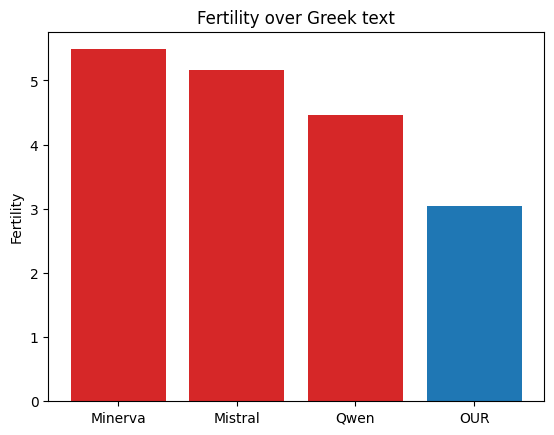

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

models = ['Minerva', 'Mistral', 'Qwen', 'OUR']
counts = [minerva_greek_analysis, mistral_greek_analysis, qwen_greek_analysis, bg_greek_analysis]
bar_colors = ['tab:red', 'tab:red', 'tab:red', 'tab:blue']

ax.bar(models, counts, color=bar_colors)

ax.set_ylabel('Fertility')
ax.set_title('Fertility over Greek text')

plt.show()

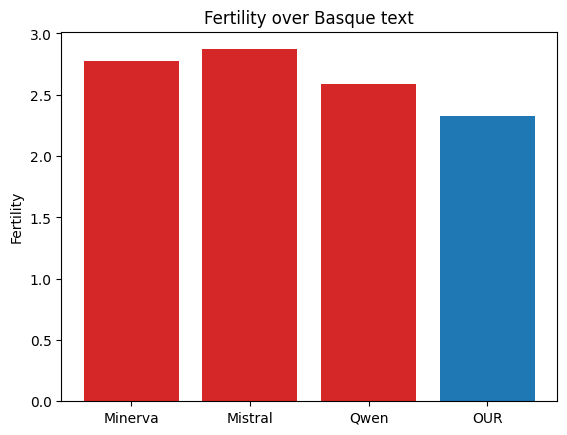

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

models = ['Minerva', 'Mistral', 'Qwen', 'OUR']
counts = [minerva_basque_analysis, mistral_basque_analysis, qwen_basque_analysis, bg_basque_analysis]
bar_colors = ['tab:red', 'tab:red', 'tab:red', 'tab:blue']

ax.bar(models, counts, color=bar_colors)

ax.set_ylabel('Fertility')
ax.set_title('Fertility over Basque text')

plt.show()

#Considerations

We observe that the Greek-Basque tokenizer achieves lower perplexity than the other tokenizers.

This highlights the importance of ensuring adequate language coverage in the data used to train a tokenizer. When the tokenizer is trained on data that properly represents the target languages, it can produce more effective segmentations, which in turn improves overall model performance.

Since the tokenizer introduces an architectural bias, hard to recover, and given the significant computational cost required to train a language model (we will see), it is crucial to carefully design the tokenizer’s rules. In particular, proper data selection and well-designed pre-tokenization steps are essential to ensure robust and efficient learning.